# NLP for Other Languages

In [1]:
! pip install indic-nlp-datasets==0.1.2

In [11]:
from idatasets import load_devdas

In [12]:
devdas = load_devdas()
para = list(devdas.data)
# devdas.data is a generator of paragraphs
text = " ".join(para)
words = text.split(" ")

In [13]:
from collections import Counter
count = Counter(words)

In [14]:
count.most_common(10)

[('के', 696),
 ('ने', 676),
 ('नही', 672),
 ('से', 626),
 ('मे', 562),
 ('की', 480),
 ('है', 444),
 ('देवदास', 437),
 ('को', 336),
 ('पार्वती', 332)]

In [15]:
from spacy.lang.hi import Hindi
lang = Hindi()
doc = lang(text)
not_stopwords = []
for token in doc:
    if token.is_stop:
        continue
    if token.is_punct or token.text == "|":
        continue
    not_stopwords.append(token.text)

In [16]:
not_stopcount = Counter(not_stopwords)
not_stopcount.most_common(10)

[('नही', 782),
 ('देवदास', 472),
 ('कहा-', 390),
 ('पार्वती', 345),
 ('क्या', 237),
 ('दिन', 187),
 ('बात', 168),
 ('तुम', 168),
 ('मै', 160),
 ('चन्द्रमुखी', 154)]

In [17]:
from wordcloud import WordCloud
from spacy.lang.hi import STOP_WORDS as STOP_WORDS_HI
import matplotlib.pyplot as plt

In [18]:
import requests
url = "https://hindityping.info/download/assets/Hindi-Fonts-Unicode/gargi.ttf"
r = requests.get(url, allow_redirects = True)
font_path = "gargi.ttf"
with open(font_path, "wb") as fw:
    fw.write(r.content)

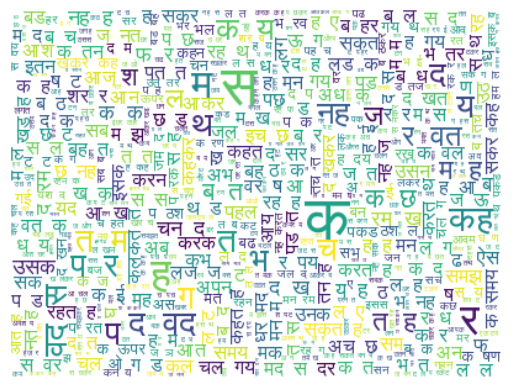

In [20]:
wordcloud = WordCloud(width = 400, height = 300, max_font_size = 50, max_words = 1000, background_color = "white", stopwords = STOP_WORDS_HI, font_path = font_path).generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

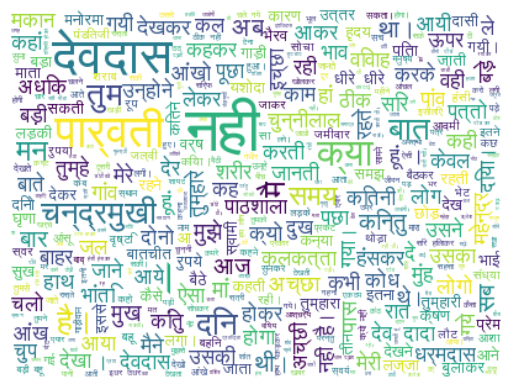

In [21]:
wordcloud = WordCloud(width = 400, height = 300, max_font_size = 50, max_words = 1000, background_color = "white", stopwords = STOP_WORDS_HI, regexp=r"[\u0900-\u097F]+", font_path = font_path).generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()